# Features importance

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from boruta import BorutaPy

In [2]:
# Load formatted cytokines data
cytokines_df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260729.csv")

In [3]:
cytokines_df.head()

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,symptomscore,globalhealthstatusql2,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,19.44,75.00,81.62,30.56,stage_I,no,no,alive,1839,alive
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,59.03,16.67,46.11,47.78,stage_IV,no,yes,alive,1721,alive
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,31.25,50.00,57.56,45.68,stage_IV,yes,no,death,48,death
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,68.75,0.00,19.23,94.44,stage_IV,no,yes,death,131,death
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,27.08,75.00,76.67,17.44,stage_II,no,no,alive,1679,alive


In [4]:
cytokines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   sample_names                   212 non-null    str    
 1   sample_id                      212 non-null    str    
 2   cohort                         212 non-null    str    
 3   egf                            212 non-null    float64
 4   ifnalpha2                      212 non-null    float64
 5   ifngamma                       212 non-null    float64
 6   il1alpha                       212 non-null    float64
 7   il1beta                        212 non-null    float64
 8   il4                            212 non-null    float64
 9   il6                            212 non-null    float64
 10  il8                            212 non-null    float64
 11  il10                           212 non-null    float64
 12  mip1alpha                      212 non-null    float64
 13  t

In [5]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "sample_names", "sample_id", "cohort", "ages", "sex", "race", "tobaccouse", "packyears", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

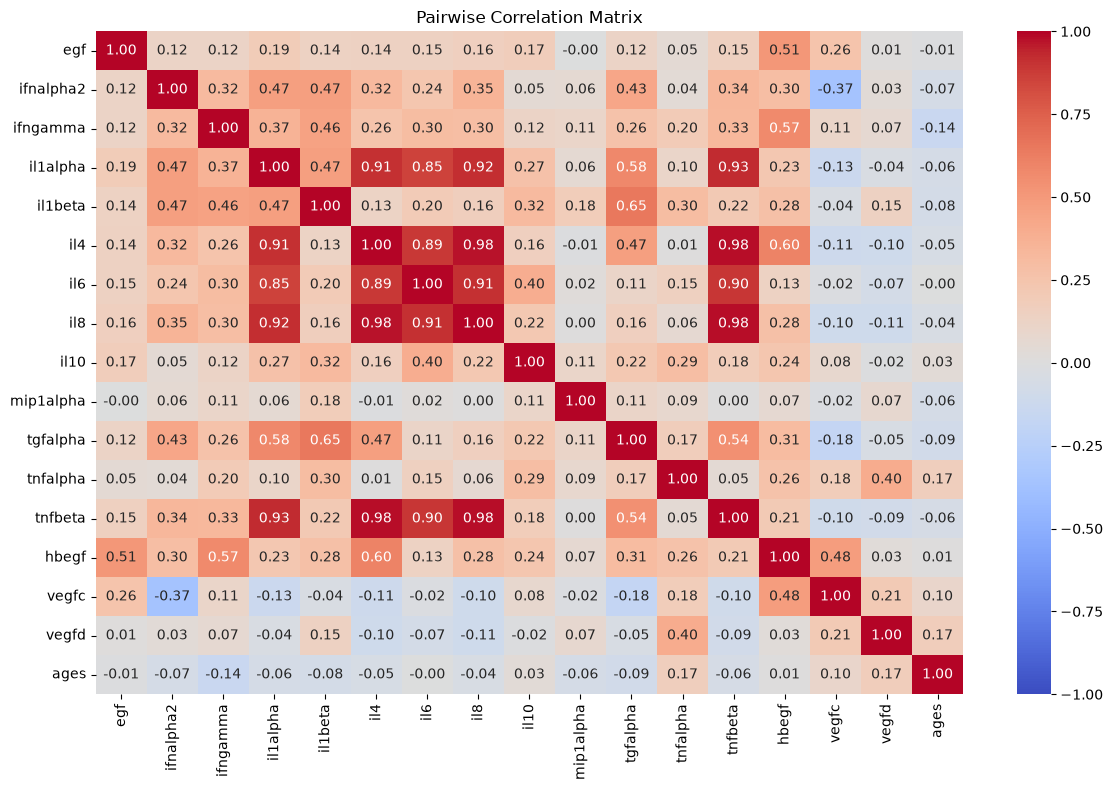

In [6]:
# Select only the cytokine variables and ages for correlation analysis
corr_df = cytokines_df[cytokines + ["ages"]]

# Compute the pairwise correlation matrix
corr_matrix = corr_df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
# Define predictor variables to test for multicollinearity
# Drop "hbegf" and "tgfalpha" because of high percentages of missing values
predictor_vars = corr_df.drop(columns=["hbegf", "tgfalpha"])

# Add constant to the model (intercept)
predictor_vars = add_constant(predictor_vars)

# Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df["Feature"] = predictor_vars.columns
vif_df["VIF"] = [variance_inflation_factor(predictor_vars.values, i) for i in range(predictor_vars.shape[1])]

# Sort the VIF dataframe by VIF values in descending order
vif_df = vif_df.sort_values(by="VIF", ascending=False)
vif_df

,Feature,VIF
6,il4,46.101270
12,tnfbeta,42.328439
8,il8,40.278542
4,il1alpha,30.204954
0,const,29.257297
7,il6,8.717530
5,il1beta,6.298692
2,ifnalpha2,1.977238
9,il10,1.820262
3,ifngamma,1.606781


In [8]:
# Select features with VIF <= 5
predictor_vars_filtered = vif_df[vif_df["VIF"] <= 5].Feature.tolist()
print("Features with VIF <= 5:", predictor_vars_filtered)

Features with VIF <= 5: ['ifnalpha2', 'il10', 'ifngamma', 'tnfalpha', 'vegfc', 'vegfd', 'egf', 'ages', 'mip1alpha']


## Set up preprocessing steps

In [9]:
# Specify the predictor variables and target variable
numeric_features = predictor_vars_filtered
categorical_features = ["sex", "race", "pathologicstage", "lvi", "pni"]
target_var = "survival_2yrs"

In [10]:
# Specify features
X = cytokines_df[numeric_features + categorical_features]
X

,ifnalpha2,il10,ifngamma,tnfalpha,vegfc,vegfd,egf,ages,mip1alpha,sex,race,pathologicstage,lvi,pni
0,25.24,3.92,90.00,18.74,381.47,263.05,29.45,67,25.93,female,white_nonhispanic,stage_I,no,no
1,9.93,75.20,46.35,25.54,923.75,237.53,71.50,68,2.90,male,white_nonhispanic,stage_IV,no,yes
2,18.38,98.33,54.01,22.39,490.19,130.47,54.54,78,25.05,male,white_nonhispanic,stage_IV,yes,no
3,27.47,20.63,81.82,28.18,1148.22,34.22,132.67,49,20.32,male,white_nonhispanic,stage_IV,no,yes
4,13.63,10.63,66.20,39.61,1113.45,142.55,28.01,65,17.14,female,white_nonhispanic,stage_II,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,122.36,168.84,103.74,19.66,289.94,91.56,61.90,60,18.23,female,white_nonhispanic,stage_V,yes,yes
208,91.86,82.12,71.49,26.21,234.20,65.32,18.86,74,10.90,female,white_nonhispanic,stage_II,no,no
209,66.46,7.41,51.61,13.77,144.61,55.09,12.99,60,9.54,male,white_nonhispanic,stage_III,yes,yes
210,75.02,12.45,40.79,16.65,158.81,21.47,13.66,71,6.71,male,white_nonhispanic,stage_II,no,no


In [11]:
# Specify the target variable
y = cytokines_df[target_var]
y

0      alive
1      alive
2      death
3      death
4      alive
       ...  
207    alive
208    alive
209    alive
210    alive
211    alive
Name: survival_2yrs, Length: 212, dtype: str

In [12]:
# Features scaling and encoding
numeric_transformer = Pipeline(
    steps=[
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", RobustScaler())
    ]
)

ct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(sparse_output=False), categorical_features),
    ],
    remainder="drop"
).set_output(transform="pandas")

X_transformed = ct.fit_transform(X)
X_transformed

,num__ifnalpha2,num__il10,num__ifngamma,num__tnfalpha,num__vegfc,num__vegfd,num__egf,num__ages,num__mip1alpha,cat__sex_female,...,cat__race_white_nonhispanic,cat__pathologicstage_stage_I,cat__pathologicstage_stage_II,cat__pathologicstage_stage_III,cat__pathologicstage_stage_IV,cat__pathologicstage_stage_V,cat__lvi_no,cat__lvi_yes,cat__pni_no,cat__pni_yes
0,-0.133254,-0.909407,0.866271,0.497890,0.137953,0.817976,0.255824,0.105440,1.184080,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.536377,1.144218,0.034648,1.129180,0.916013,0.730988,0.960716,0.157003,-1.182103,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,-0.272746,1.342896,0.225528,0.859726,0.358433,0.221164,0.744184,0.635028,1.143396,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,-0.095709,0.200408,0.746370,1.331424,1.107529,-0.906087,1.457827,-0.980593,0.898027,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.402169,-0.264641,0.480324,2.036345,1.080454,0.296394,0.216460,0.000000,0.700228,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,0.579216,1.744926,1.045278,0.595039,-0.103106,-0.079161,0.845301,-0.278254,0.771684,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
208,0.448483,1.209366,0.576783,1.182351,-0.290538,-0.364460,-0.091444,0.451507,0.183975,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
209,0.301389,-0.507599,0.168742,-0.120696,-0.713117,-0.507839,-0.376135,-0.278254,0.035360,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
210,0.356378,-0.155673,-0.124358,0.259217,-0.631110,-1.290719,-0.338124,0.307324,-0.347511,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [13]:
# Encode the target separately
le = LabelEncoder()
y_transformed = le.fit_transform(y)
y_transformed

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Random forest feature importance

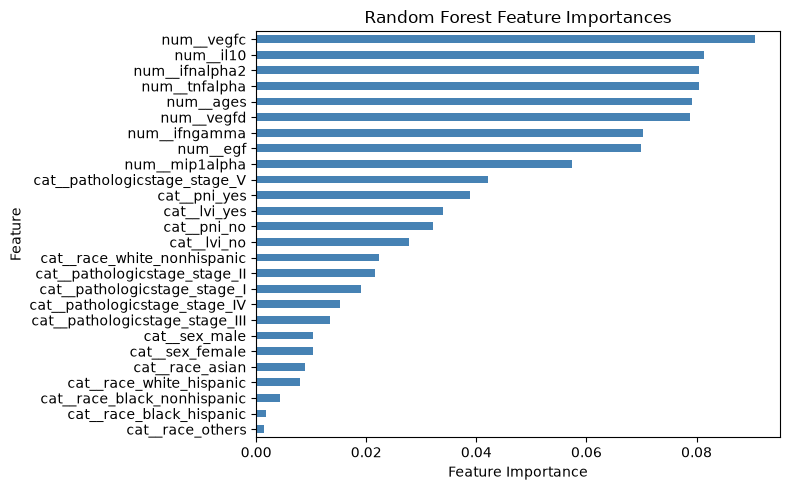

In [14]:
# Train a Random Forest Classifier on the selected features
rfc = RandomForestClassifier(n_estimators=500, max_depth=15, class_weight="balanced_subsample", random_state=2026)
rfc.fit(X_transformed, y_transformed)

# Get feature importances from the trained Random Forest model
importances_rf = pd.Series(rfc.feature_importances_, index=X_transformed.columns).sort_values()

# Visualize the feature importances from RF classifier
plt.figure(figsize=(8, 5))
importances_rf.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Boruta feature importance

In [15]:
# Feature seclection using Boruta
boruta = BorutaPy(
    estimator=rfc,
    n_estimators=100 
)
boruta.fit(X_transformed, y_transformed)

,estimator,RandomForestC...x7D24CC0A2940)
,n_estimators,100
,random_state,RandomState(M...0x7D24CC0A2940
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,verbose,0
,early_stopping,False
,n_iter_no_change,20
Name,Type,Value


In [16]:
# Boolean array: True = confirmed important feature
print("Confirmed features:", X_transformed.columns[boruta.support_].tolist())

# Boolean array: True = tentative feature (borderline, undecided)
print("Tentative features:", X_transformed.columns[boruta.support_weak_].tolist())

# Ranking: 1 = confirmed, higher numbers = progressively less important/rejected earlier
ranking_df = pd.DataFrame({
    'feature': X_transformed.columns,
    'ranking': boruta.ranking_,
    'confirmed': boruta.support_,
    'tentative': boruta.support_weak_
}).sort_values('ranking')

ranking_df

Confirmed features: ['num__ifnalpha2', 'num__tnfalpha', 'num__vegfc']
Tentative features: ['num__il10', 'num__vegfd']


,feature,ranking,confirmed,tentative
0,num__ifnalpha2,1,True,False
3,num__tnfalpha,1,True,False
4,num__vegfc,1,True,False
1,num__il10,2,False,True
5,num__vegfd,2,False,True
7,num__ages,3,False,False
6,num__egf,4,False,False
2,num__ifngamma,5,False,False
21,cat__pathologicstage_stage_V,6,False,False
25,cat__pni_yes,7,False,False


## Recursive feature elimination with cross-validation (RFECV)

In [22]:
# Feature selection using recursive feature elimination (RFE) with cross-validation
rfecv = RFECV(
    estimator=rfc,
    step=1,
    cv=5,
    scoring="accuracy",
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X_transformed, y_transformed)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 23


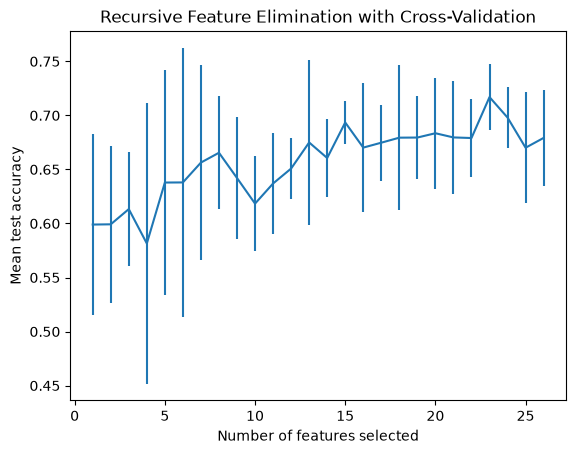

In [23]:
# Plot number of features vs. cross-validation scores
data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination with Cross-Validation")
plt.show()